# 2.4 Evaluating Hyperparameters - Part 1b Random Forest MAASTRICHT

## Table of contents

### 01 Load Libraries & Dataset
### 02 Clean & Wrangle
### 03 Shaping Data
### 04 Spliting Data
### 05 Hyperparameter Optimisation
    - a. Grid Search
    - b. Random Search
### 06 Running Random Forest with Optimized Search Parameters
### 07 Insights - Feature Importances

### 01 Load Libraries & Dataset

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
import time
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

In [5]:
# Create a path for the import of dataset

path = r'C:\Users\wallm\02 2025 Machine Learning Project\02 Data'

In [11]:
# Import weather dataset

climate = pd.read_csv(os.path.join(path, '02 Prepared Data', 'Dataset-weather-cleaned-reshaped.csv'))

In [13]:
climate.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,STOCKHOLM_humidity,MUNCHENB_pressure
0,19600101,-1.6,0.661,0.826,-0.002,-1.101,-0.265,-0.903,-0.529,-0.846,...,-1.300,-0.806,-0.088,0.372,-0.668,-0.520,-0.752,0.714,1.544,0.095
1,19600102,-1.6,0.245,0.736,-0.002,-1.058,1.659,-0.810,-0.583,-0.462,...,-1.262,-1.042,0.503,-0.829,-0.548,-0.629,-0.407,1.176,-0.712,0.067
2,19600103,-1.6,1.076,1.278,-0.002,-1.251,0.156,-1.065,-0.257,-0.187,...,-0.433,-1.136,-0.396,-1.010,-0.067,0.054,-0.177,0.252,-0.274,0.132
3,19600104,-1.6,-1.002,1.458,-0.002,-0.822,-0.446,-0.114,-0.556,-0.386,...,0.388,-1.183,0.669,-1.040,-0.999,-0.164,-0.839,1.176,1.544,0.419
4,19600105,-1.6,0.245,1.729,-0.002,-0.747,-0.165,0.187,-1.004,-1.076,...,1.730,-0.795,-0.491,0.673,-1.509,-1.340,-1.471,0.252,1.419,0.388


In [15]:
climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22950 entries, 0 to 22949
Columns: 137 entries, DATE to MUNCHENB_pressure
dtypes: float64(136), int64(1)
memory usage: 24.0 MB


In [17]:
climate.shape

(22950, 137)

In [19]:
# Import the 'Pleasant weather' dataset

pleasantweather = pd.read_csv(os.path.join(path, '01 Original Data', 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [21]:
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [23]:
pleasantweather.shape

(22950, 16)

### 02 Clean & Wrangle

In [28]:
climate.isnull().sum()

DATE                  0
MONTH                 0
BASEL_cloud_cover     0
BASEL_humidity        0
BASEL_pressure        0
                     ..
VALENTIA_temp_min     0
VALENTIA_temp_max     0
KASSEL_cloud_cover    0
STOCKHOLM_humidity    0
MUNCHENB_pressure     0
Length: 137, dtype: int64

In [30]:
pleasantweather.isnull().sum()

DATE                           0
BASEL_pleasant_weather         0
BELGRADE_pleasant_weather      0
BUDAPEST_pleasant_weather      0
DEBILT_pleasant_weather        0
DUSSELDORF_pleasant_weather    0
HEATHROW_pleasant_weather      0
KASSEL_pleasant_weather        0
LJUBLJANA_pleasant_weather     0
MAASTRICHT_pleasant_weather    0
MADRID_pleasant_weather        0
MUNCHENB_pleasant_weather      0
OSLO_pleasant_weather          0
SONNBLICK_pleasant_weather     0
STOCKHOLM_pleasant_weather     0
VALENTIA_pleasant_weather      0
dtype: int64

In [34]:
# Create a list of the columns containing "" in their names

MAASTRICHT_list = list(x for x in climate.columns if x.find('MAASTRICHT') >=0)
MAASTRICHT_list

['MAASTRICHT_cloud_cover',
 'MAASTRICHT_humidity',
 'MAASTRICHT_pressure',
 'MAASTRICHT_global_radiation',
 'MAASTRICHT_precipitation',
 'MAASTRICHT_sunshine',
 'MAASTRICHT_temp_mean',
 'MAASTRICHT_temp_min',
 'MAASTRICHT_temp_max']

In [38]:
# Create a dataframe with those columns

climate_MAASTRICHT= climate[MAASTRICHT_list]
climate_MAASTRICHT

,MAASTRICHT_cloud_cover,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max
0,0.704,0.268,-1.044,-1.052,0.252,-0.811,-0.097,0.383,-0.388
1,1.146,1.072,-1.055,-1.108,2.569,-0.959,-0.232,0.216,-0.543
2,0.704,1.519,0.074,-1.163,0.571,-1.058,-0.487,-0.118,-0.543
3,0.704,0.804,1.257,-1.119,-0.474,-0.984,-0.472,-0.535,-0.530
4,0.704,1.072,1.063,-1.163,0.798,-1.058,-0.307,-0.618,-0.388
...,...,...,...,...,...,...,...,...,...
22945,1.146,-1.162,0.440,-0.001,-0.020,0.251,1.268,1.317,1.094
22946,0.704,-0.894,0.322,-0.001,-0.020,0.177,1.313,1.601,1.210
22947,1.146,-0.984,0.246,-0.001,-0.020,-0.268,1.208,1.251,1.313
22948,1.146,-0.626,0.225,-0.001,-0.020,0.621,0.923,1.100,0.939


In [42]:
# Reduce pleasantweather dataset to MAASTRICHT's answers only

pleasantweather_MAASTRICHT = pleasantweather['MAASTRICHT_pleasant_weather']
pleasantweather_MAASTRICHT

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: MAASTRICHT_pleasant_weather, Length: 22950, dtype: int64

In [44]:
climate_MAASTRICHT.shape

(22950, 9)

In [46]:
pleasantweather_MAASTRICHT.shape

(22950,)

### 03 Shaping Data

In [52]:
# Assign the features and labels for the MAASTRICHT dataset

# X2 will contain the weather observation features (e.g., temperature, wind, humidity) for MAASTRICHT
X2 = climate_MAASTRICHT

# y2 will contain the corresponding "pleasant/unpleasant" target values for MAASTRICHT
y2 = pleasantweather_MAASTRICHT

In [54]:
### Convert both DataFrames into NumPy arrays

# Most machine learning models in scikit-learn work with arrays, not DataFrames.
# So we convert our pandas DataFrames into numpy arrays.

X = np.array(X2)  # Features
y = np.array(y2)  # Labels

In [56]:
### Check the shape of your data

# This helps confirm that your data is correctly structured and aligned.
# X should be a 2D array: rows = number of samples, columns = number of features
# y should be a 1D array: number of labels matching number of rows in X

print("Shape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)

Shape of X (features): (22950, 9)
Shape of y (labels): (22950,)


### 04 Spliting Data

In [60]:
# Now split our features (X) and labels (y) into two groups:
#  - Training set (used to train the model)
#  - Testing set (used to evaluate how well the model performs on unseen data)

# Set aside 25% of the data for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,        # 25% of the data will be for testing
    random_state=42       # Random seed for reproducibility
)

# Confirm the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17212, 9)
X_test shape: (5738, 9)
y_train shape: (17212,)
y_test shape: (5738,)


### 05 Hyperparameter Optimisation

#### a. Grid Search

In [66]:
# Create the Random Forest classifier

clf = RandomForestClassifier(random_state=42)

In [68]:
# Define the hyperparameter search space

param_grid = {
    'max_depth': [3, 10, None],             # Try shallow, medium, and unlimited depth
    'n_estimators': [50, 100],              # Number of trees in the forest
    'max_features': [5, 9],                 # Since MAASTRICHT only has 9 features, use lower max
    'min_samples_leaf': [1, 2],             # How many samples at each leaf
    'min_samples_split': [2, 3]             # Minimum samples required to split
}

In [70]:
# Run GridSearchCV to find the best combination

start = time.time()

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=3,
    n_jobs=-1
)

model_grid = grid_search.fit(X_train, y_train)

print("Search took %.2f minutes" % ((time.time() - start) / 60))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Search took 0.46 minutes


In [72]:
# Display the best parameters and score

print("Best GRID search hyperparameters are:", model_grid.best_params_)
print("Best GRID search score: %.4f" % model_grid.best_score_)

Best GRID search hyperparameters are: {'max_depth': 3, 'max_features': 9, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best GRID search score: 1.0000


##### As before (with 2010 data set for ALL stations), a perfect score (1.0000) can be a sign of overfitting!

#### b. Random Search

In [ ]:
### Define search space

param_distributions = {
    'max_depth': list(np.arange(3, 20, 3)) + [None],   # Up to 20 or unlimited
    'n_estimators': np.arange(50, 300, 50),            # 50 to 250 trees
    'max_features': np.arange(3, 10),                  # MAASTRICHT only has 9 total features
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': np.arange(1, 4),
    'min_samples_split': np.arange(2, 6)
}

# Create classifier
rf = RandomForestClassifier(random_state=42)

# Run Randomized Search
start = time.time()

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=20,               # Start small for speed — increase once working
    scoring='accuracy',
    cv=3,
    verbose=3,
    n_jobs=-1,
    random_state=42
)

model_random = random_search.fit(X_train, y_train)

print("Search took %.2f minutes" % ((time.time() - start) / 60))

In [79]:
# Print best parameters and score

print("Best RANDOM search hyperparameters:", model_random.best_params_)
print("Best RANDOM search score: %.4f" % model_random.best_score_)

Best RANDOM search hyperparameters: {'n_estimators': 50, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 8, 'max_depth': 18, 'criterion': 'entropy'}
Best RANDOM search score: 1.0000


### Both Grid Search and Random Search returned models with a perfect cross-validation score of 1.0000. While this indicates excellent fit on the training data, it also raises the possibility of overfitting.

After comparing the results, I selected the Grid Search model to proceed for the following reasons:

- Grid Search yielded a **shallower tree** (max_depth = 3), which is **less prone to overfitting** and easier to interpret.
- It used **fewer parameters** overall, leading to **simpler and faster** training.
- The model’s accuracy on the **test set** will confirm whether this conservative choice generalizes well.

### 06 Running Random Forest with Optimized Search Parameters

In [86]:
# Create a RF classifier with the best GRID search parameters

grid_best_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    max_features=9,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

# Train the model
grid_best_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, max_features=9, n_estimators=50,
                       random_state=42)

In [88]:
# Predict on test data

y_pred_grid = grid_best_rf.predict(X_test)

# Accuracy score

from sklearn.metrics import accuracy_score
print("Model Accuracy (Grid):", accuracy_score(y_test, y_pred_grid))

Model Accuracy (Grid): 1.0


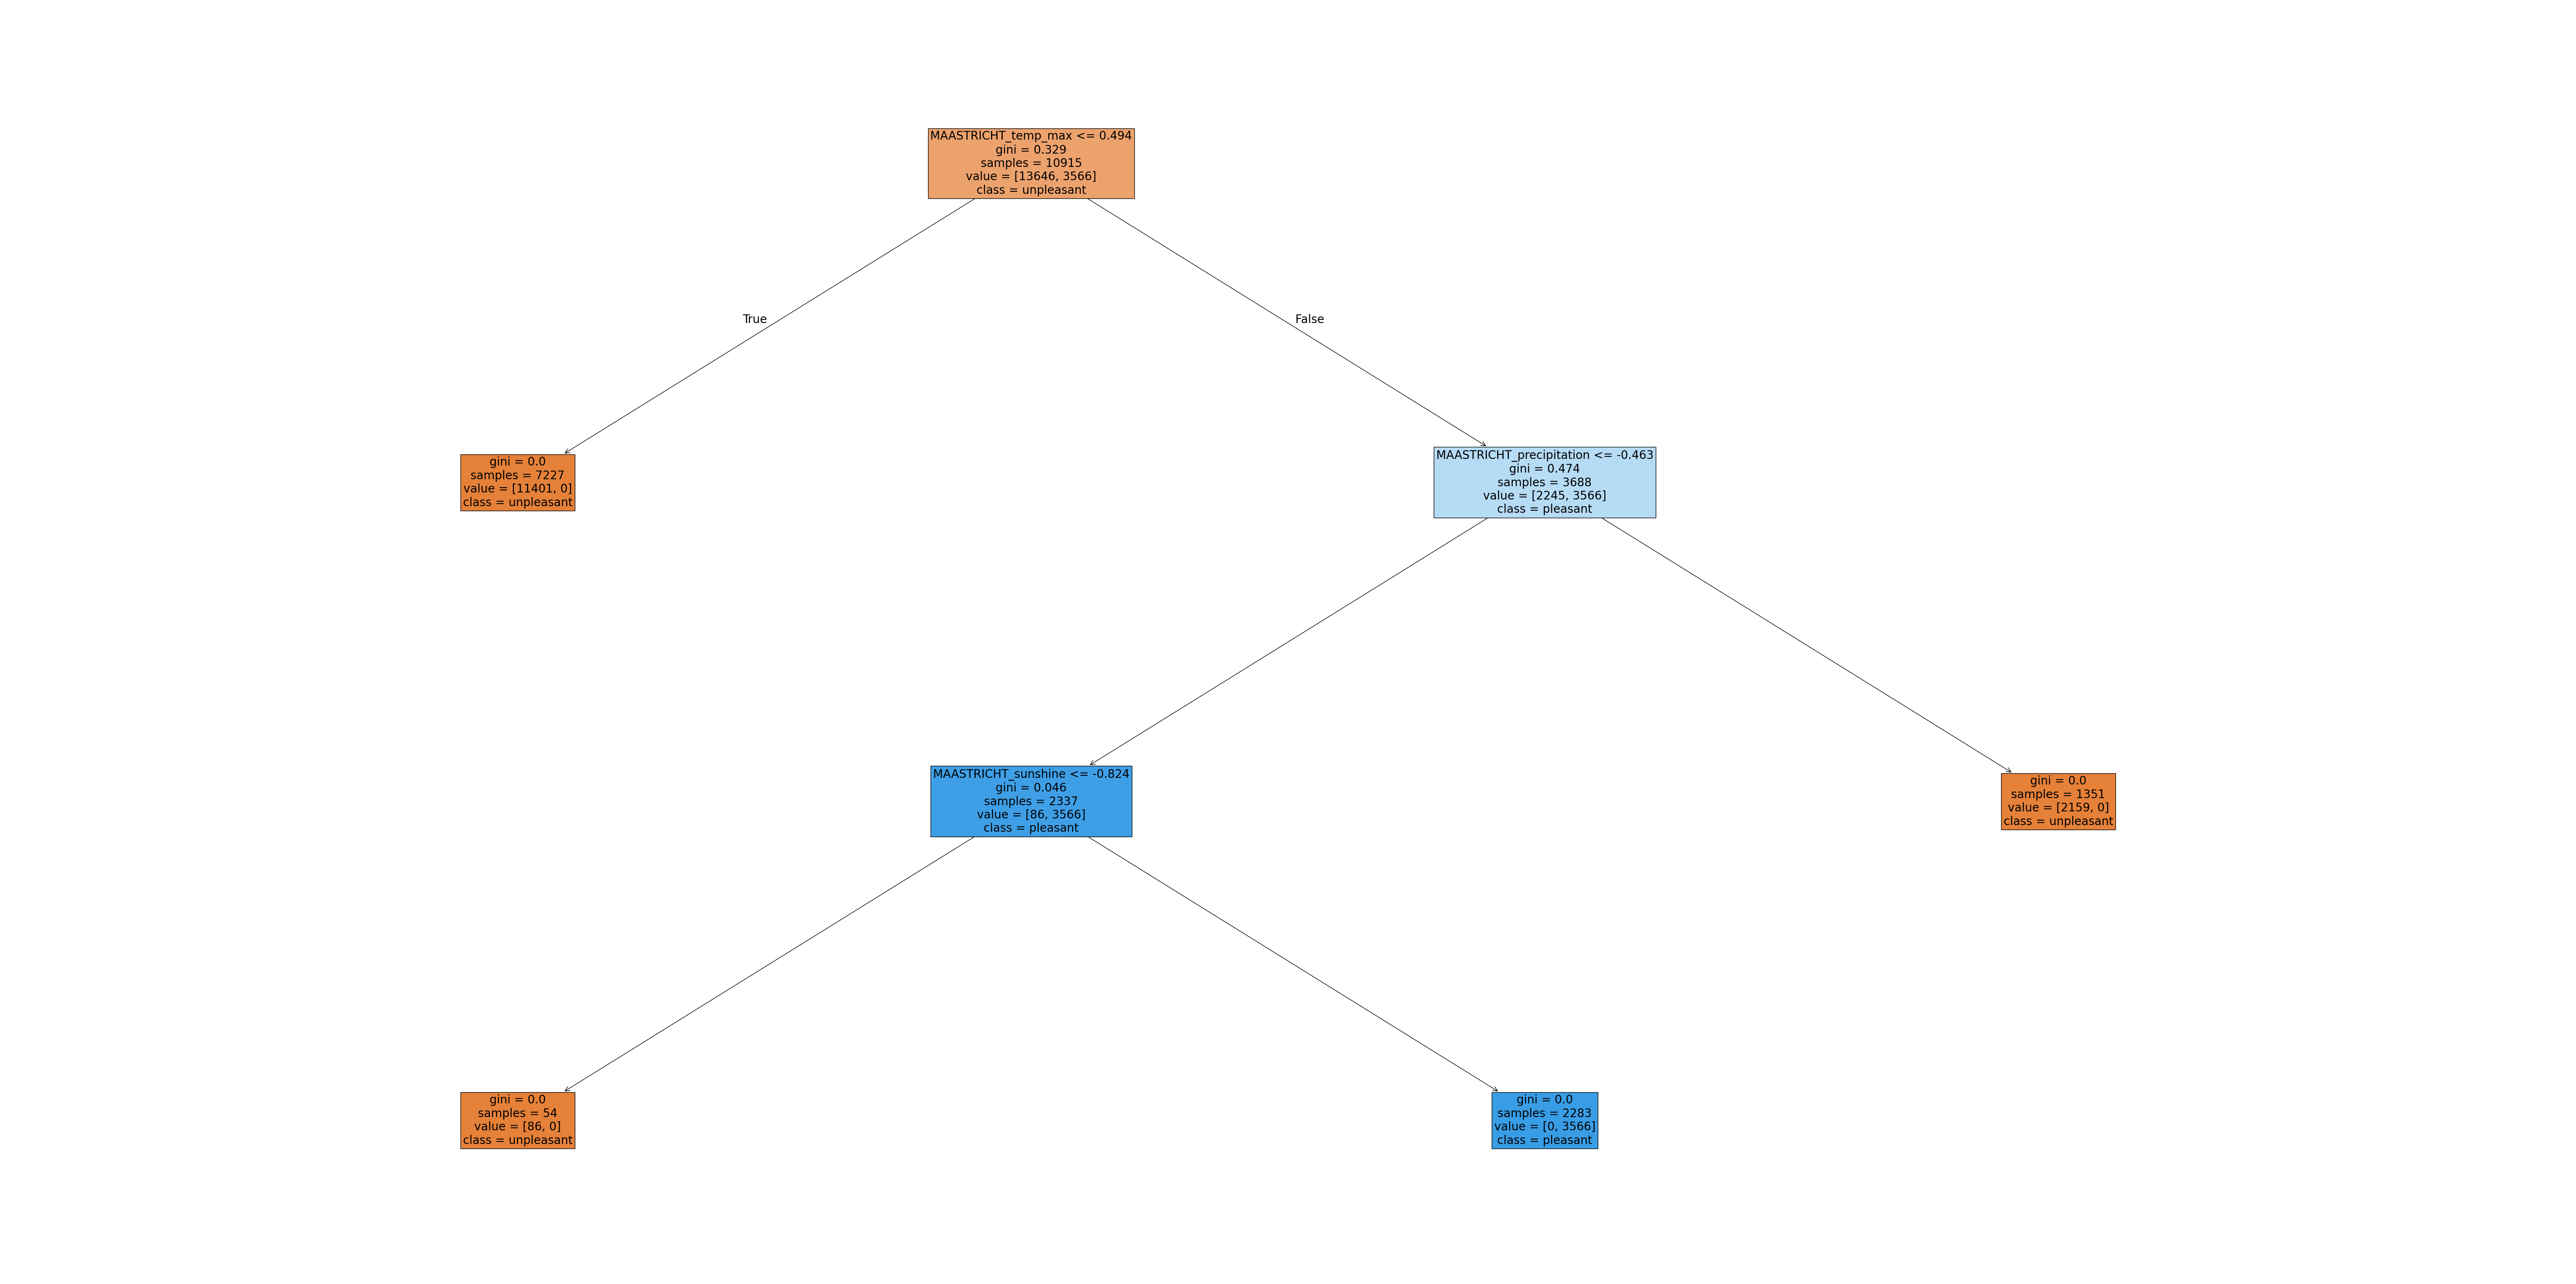

In [90]:
# Plot one of the trees in the Random Forest

fig = plt.figure(figsize=(80, 40))
plot_tree(grid_best_rf.estimators_[0],  # You can pick another index if preferred
          fontsize=20,
          feature_names=climate_MAASTRICHT.columns,
          class_names=['unpleasant', 'pleasant'],
          filled=True)
plt.show()

In [ ]:
#### SAVE image

### 07 Insights - Feature Importances

In [94]:
# Retrieve Feature Importances from the Trained Model

newarray = grid_best_rf.feature_importances_
print(grid_best_rf.feature_importances_.shape)
newarray

(9,)


array([0.        , 0.        , 0.        , 0.        , 0.45742307,
       0.03120182, 0.        , 0.        , 0.51137511])

In [96]:
# Create list of weather features (removing 'MAASTRICHT_' prefix)

wx_list = [feature.replace('MAASTRICHT_', '') for feature in climate_MAASTRICHT.columns]
wx_list

['cloud_cover',
 'humidity',
 'pressure',
 'global_radiation',
 'precipitation',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [98]:
# Create a Series to pair feature names with importances

important = pd.Series(newarray, index=wx_list)
important.sort_values(ascending=False, inplace=True)
important

temp_max            0.511375
precipitation       0.457423
sunshine            0.031202
cloud_cover         0.000000
humidity            0.000000
pressure            0.000000
global_radiation    0.000000
temp_mean           0.000000
temp_min            0.000000
dtype: float64

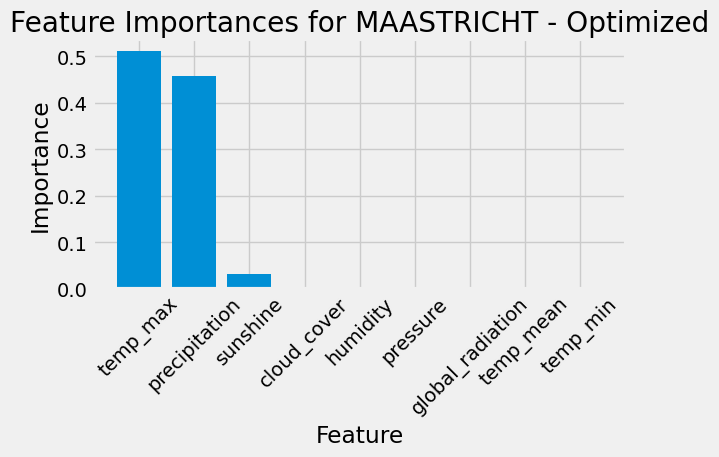

In [61]:
# Plot the results

plt.style.use('fivethirtyeight')
x_values = list(range(len(important)))

plt.bar(x_values, important.values, orientation='vertical')
plt.xticks(x_values, important.index, rotation=45)
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.title('Feature Importances for MAASTRICHT - Optimized')

plt.tight_layout()
plt.show()

### Summary of MAASTRICHT Feature Importance (Optimised Model)

The optimized Random Forest model identified **temp-max** and **precipitation** as the two most important weather features 
when predicting if the weather is pleasant for flying in Maastricht.

Together, these two features contribute over **96%** of the model’s decision-making power, sunshine accounting for over 3%

Other weather features — such as pressure, temperature, precipitation, and sunshine — had little to no influence on the model’s predictions.

This suggests that **monitoring temp-max and precipitation** at Maastricht could be the most effective way to forecast safe flying conditions.